# 01 — Exploratory Data Analysis

**Goal:** understand the dataset well enough to frame a profit-optimization problem.

By the end of this notebook we should know:
- How many loans we have, the time range, and the share that have a final outcome
- The base default rate and how it shifts over time
- What missingness looks like and which fields are leakage (post-issuance)
- Distributions of headline features (loan_amnt, int_rate, dti, fico, grade, purpose)
- A baseline profit number under three trivial policies: approve-all, approve-none, FICO cutoff

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from credit_risk import data as cr_data

sns.set_style("whitegrid")
pd.set_option("display.max_columns", 100)

## Load and inspect

In [2]:
df_raw = cr_data.load_raw()
print(f"Rows: {len(df_raw):,}")
print(f"Columns: {df_raw.shape[1]}")
print(f"Date range: {df_raw['issue_d'].min().date()} -> {df_raw['issue_d'].max().date()}")
df_raw.head()

Rows: 2,260,701
Columns: 151
Date range: 2007-06-01 -> 2018-12-01


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,...,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_fico_range_low,sec_app_fico_range_high,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,10+ years,MORTGAGE,55000.0,Not Verified,2015-12-01,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,190xx,PA,5.91,0.0,Aug-2003,675.0,679.0,1.0,30.0,NaN,7.0,0.0,2765.0,29.7,13.0,w,0.00,0.00,4421.723917,4421.72,3600.00,821.72,0.0,0.0,0.0,Jan-2019,122.67,NaN,...,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,10+ years,MORTGAGE,65000.0,Not Verified,2015-12-01,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,small_business,Business,577xx,SD,16.06,1.0,Dec-1999,715.0,719.0,4.0,6.0,NaN,22.0,0.0,21470.0,19.2,38.0,w,0.00,0.00,25679.660000,25679.66,24700.00,979.66,0.0,0.0,0.0,Jun-2016,926.35,NaN,...,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,10+ years,MORTGAGE,63000.0,Not Verified,2015-12-01,Fully Paid,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,home_improvement,NaN,605xx,IL,10.78,0.0,Aug-2000,695.0,699.0,0.0,NaN,NaN,6.0,0.0,7869.0,56.2,18.0,w,0.00,0.00,22705.924294,22705.92,20000.00,2705.92,0.0,0.0,0.0,Jun-2017,15813.30,NaN,...,3.0,6.0,0.0,0.0,0.0,0.0,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,Information Systems Officer,10+ years,MORTGAGE,110000.0,Source Verified,2015-12-01,Current,n,https://lendingclub.com/browse/loanDetail.acti...,NaN,debt_consolidation,Debt consolidation,076xx,NJ,17.06,0.0,Sep-2008,785.0,789.0,0.0,NaN,NaN,13.0,0.0,7802.0,11.6,17.0,w,15897.65,15897.65,31464.010000,31464.01,19102.35,12361.66,0.0,0.0,0.0,Feb-2019,829.90,Apr-2019,...,5.0,13.0,0.0,0.0,0.0,1.0,100.0,0.0,0.0,0.0,381215.0,52226.0,62500.0,18000.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,

In [3]:
# Outcome distribution. Anything other than Fully Paid / Charged Off is in-flight
# and can't be used (we don't yet know how it ends).
df_raw["loan_status"].value_counts(dropna=False)

loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40
NaN                                                         33
Name: count, dtype: int64

In [4]:
df = cr_data.filter_to_completed_loans(df_raw)
print(f"Completed loans: {len(df):,}  ({len(df)/len(df_raw):.1%} of raw)")
df["loan_status"].value_counts()

Completed loans: 1,345,310  (59.5% of raw)


loan_status
Fully Paid     1076751
Charged Off     268559
Name: count, dtype: int64

## Default rate over time

*If the default rate shifts meaningfully across vintages, we have evidence that random k-fold CV would leak future information.*

In [5]:
df["issue_year"] = df["issue_d"].dt.year
df["defaulted"] = (df["loan_status"] == "Charged Off").astype(int)

by_year = (
    df.groupby("issue_year")
    .agg(n_loans=("loan_amnt", "size"), default_rate=("defaulted", "mean"))
    .reset_index()
)
by_year

,issue_year,n_loans,default_rate
0,2007,251,0.179283
1,2008,1562,0.158131
2,2009,4716,0.125954
3,2010,11536,0.128901
4,2011,21721,0.151789
5,2012,53367,0.161973
6,2013,134804,0.155960
7,2014,223102,0.184494
8,2015,375545,0.201848
9,2016,293095,0.232832


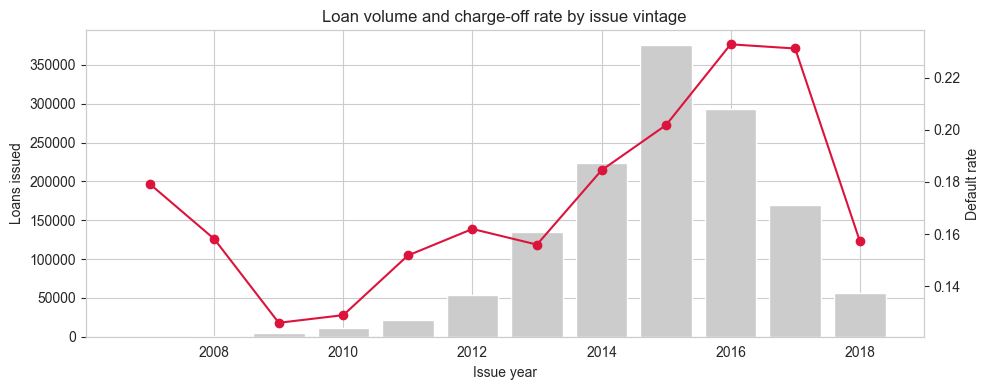

In [6]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.bar(by_year["issue_year"], by_year["n_loans"], color="#cccccc", label="loans issued")
ax1.set_ylabel("Loans issued")
ax1.set_xlabel("Issue year")

ax2 = ax1.twinx()
ax2.plot(by_year["issue_year"], by_year["default_rate"], color="crimson", marker="o", label="default rate")
ax2.set_ylabel("Default rate")
ax2.grid(False)

plt.title("Loan volume and charge-off rate by issue vintage")
plt.tight_layout()
plt.show()

## Headline feature distributions

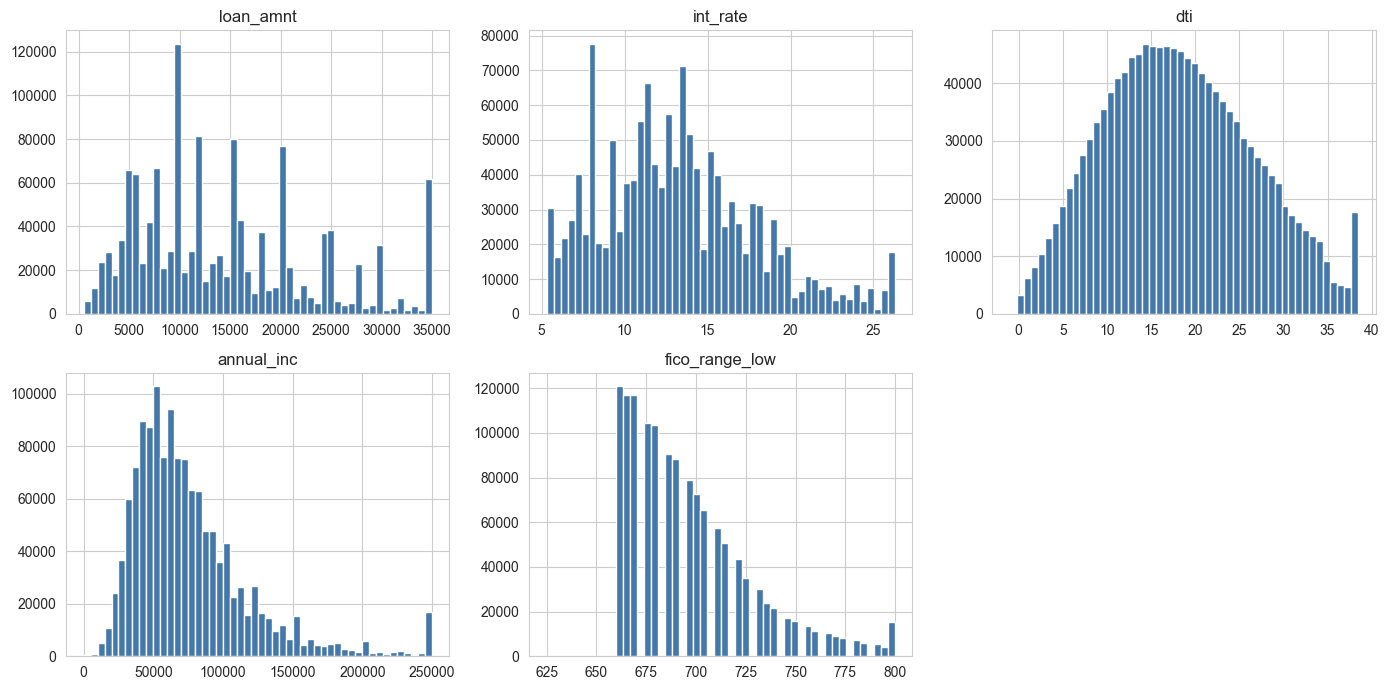

In [7]:
headline = ["loan_amnt", "int_rate", "dti", "annual_inc", "fico_range_low"]
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, headline):
    series = pd.to_numeric(df[col], errors="coerce").dropna()
    # annual_inc has a very long tail — cap at the 99th percentile for plotting
    cap = series.quantile(0.99)
    ax.hist(series.clip(upper=cap), bins=50, color="#4477aa")
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.tight_layout()
plt.show()

In [8]:
# Default rate by grade — a sanity check that LC's own grading is informative.
(
    df.groupby("grade")["defaulted"]
    .agg(["mean", "size"])
    .rename(columns={"mean": "default_rate", "size": "n_loans"})
    .sort_index()
)

,default_rate,n_loans
grade,,
A,0.060407,235090
B,0.133852,392741
C,0.224396,381686
D,0.303822,200953
E,0.384784,93650
F,0.452024,32058
G,0.499343,9132


## Leakage audit

Columns that are only known *after* the loan is issued cannot be features — they leak the outcome.
We keep them in the DataFrame for now (we need them to compute realized profit), but they will
be excluded when we build the feature matrix in notebook `02_features`.

In [9]:
leaky_present = [c for c in cr_data.POST_ISSUANCE_COLUMNS if c in df.columns]
print(f"{len(leaky_present)} post-issuance columns will be excluded from features:")
for c in leaky_present:
    print(f"  - {c}")

36 post-issuance columns will be excluded from features:
  - total_pymnt
  - total_pymnt_inv
  - total_rec_prncp
  - total_rec_int
  - total_rec_late_fee
  - recoveries
  - collection_recovery_fee
  - last_pymnt_d
  - last_pymnt_amnt
  - next_pymnt_d
  - last_credit_pull_d
  - last_fico_range_high
  - last_fico_range_low
  - out_prncp
  - out_prncp_inv
  - hardship_flag
  - hardship_type
  - hardship_reason
  - hardship_status
  - hardship_amount
  - hardship_start_date
  - hardship_end_date
  - payment_plan_start_date
  - hardship_length
  - hardship_dpd
  - hardship_loan_status
  - orig_projected_additional_accrued_interest
  - hardship_payoff_balance_amount
  - hardship_last_payment_amount
  - debt_settlement_flag
  - debt_settlement_flag_date
  - settlement_status
  - settlement_date
  - settlement_amount
  - settlement_percentage
  - settlement_term


## Maturity audit — is the test period biased?

Loans that *finalize* close to the dataset snapshot are not a random sample of their vintage. Within the 2016–2018 cohorts, only loans that paid off early or defaulted early have had time to land in a terminal status. Loans with normal timelines are still in flight (`Current`) and don't appear in our completed-loans frame at all.

Concretely: a 36-month loan issued in Jan 2018 has only had ~12 months to play out by the snapshot. The ones marked Fully Paid are mostly *early prepayers* (less interest collected). The ones marked Charged Off are *early defaulters* (more principal at risk, less recovered). Both push realized profit downward.

This is a real-world data issue, and the fix is to restrict to loans whose full term has elapsed by the snapshot date.

In [10]:
df["realized_profit"] = df["total_pymnt"] - df["funded_amnt"]

# Mean realized profit per loan, broken out by year and outcome.
# If maturity bias exists, recent-vintage Fully Paid means should drop
# (early prepayers earned less interest) and Charged Off means should drop
# (early defaulters lost more principal).
diagnostic = (
    df.groupby(["issue_year", "loan_status"])["realized_profit"]
    .agg(["mean", "size"])
    .rename(columns={"mean": "mean_profit", "size": "n_loans"})
    .round(0)
)
diagnostic

mean_profit  n_loans
issue_year loan_status                      
2007       Charged Off      -4037.0       45
           Fully Paid        1176.0      206
2008       Charged Off      -4723.0      247
           Fully Paid        1350.0     1315
2009       Charged Off      -4837.0      594
           Fully Paid        1673.0     4122
2010       Charged Off      -4124.0     1487
           Fully Paid        1997.0    10049
2011       Charged Off      -5121.0     3297
           Fully Paid        2655.0    18424
2012       Charged Off      -5228.0     8644
           Fully Paid        3004.0    44723
2013       Charged Off      -4973.0    21024
           Fully Paid        3388.0   113780
2014       Charged Off      -5403.0    41161
           Fully Paid        2897.0   181941
2015       Charged Off      -6620.0    75803
           Fully Paid        2359.0   299742
2016       Charged Off      -7662.0    68242
           Fully Paid        2006.0   224853
2017       Charged Off     -10222.0    39148
           Fully Paid        1437.0   130152
2018       Charged Off     -14338.0     8867
           Fully Paid         756.0    47444

In [11]:
# Infer the dataset snapshot from the latest credit pull date.
# `last_credit_pull_d` is updated periodically for active loans, so its max
# is a reasonable proxy for when the snapshot was taken.
snapshot = pd.to_datetime(df_raw["last_credit_pull_d"], format="%b-%Y", errors="coerce").max()
print(f"Inferred snapshot date (max last_credit_pull_d): {snapshot.date()}")

df_matured = cr_data.filter_to_matured_loans(df, snapshot_date=snapshot)
print(f"\nBefore filter: {len(df):,} loans")
print(f"After filter:  {len(df_matured):,} loans  ({len(df_matured)/len(df):.1%} kept)")

Inferred snapshot date (max last_credit_pull_d): 2019-04-01



Before filter: 1,345,310 loans
After filter:  800,634 loans  (59.5% kept)


In [12]:
# Show how the maturity filter affects each year × term combination.
before = df.assign(year=df["issue_d"].dt.year).groupby(["year", "term"]).size().rename("n_completed")
after = df_matured.assign(year=df_matured["issue_d"].dt.year).groupby(["year", "term"]).size().rename("n_matured")
maturity_summary = pd.concat([before, after], axis=1).fillna(0).astype(int)
maturity_summary["pct_kept"] = (maturity_summary["n_matured"] / maturity_summary["n_completed"]).round(2)
maturity_summary

n_completed  n_matured  pct_kept
year term                                       
2007 36 months          251        251      1.00
2008 36 months         1562       1562      1.00
2009 36 months         4716       4716      1.00
2010 36 months         8466       8466      1.00
     60 months         3070       3070      1.00
2011 36 months        14101      14101      1.00
     60 months         7620       7620      1.00
2012 36 months        43470      43470      1.00
     60 months         9897       9897      1.00
2013 36 months       100422     100422      1.00
     60 months        34382      34382      1.00
2014 36 months       162570     162570      1.00
     60 months        60532      17846      0.29
2015 36 months       283026     283026      1.00
     60 months        92519          0      0.00
2016 36 months       232353     109235      0.47
     60 months        60742          0      0.00
2017 36 months       128538          0      0.00
     60 months        40762          0      0.00
2018 36 months        41268          0      0.00
     60 months        15043          0      0.00

## Baseline profit policies (on matured loans only)

Realized profit for a completed loan is `total_pymnt - funded_amnt`:
- Positive for Fully Paid loans (interest earned net of principal)
- Negative for Charged Off loans (principal not recovered)

We compute three baselines on the **test** period of the matured dataset. Any model we build later has to beat the best of these to be worth shipping.

In [13]:
train, test = cr_data.temporal_split(df_matured)
print(f"Train (<= {cr_data.TRAIN_END_YEAR}): {len(train):,} loans")
print(f"Test  (>= {cr_data.TEST_START_YEAR}): {len(test):,} loans")

if len(test) == 0:
    print("\nWARNING: test set is empty after maturity filter.")
    print("Consider shifting TRAIN_END_YEAR earlier in credit_risk/data.py.")

Train (<= 2015): 691,399 loans
Test  (>= 2016): 109,235 loans


In [14]:
# Approve-all
approve_all = test["realized_profit"].sum()

# Approve-none — trivially zero, but stated explicitly as a sanity floor
approve_none = 0.0

# FICO cutoff: pick the cutoff that maximizes profit on the train period,
# then evaluate on the test period (no peeking). LC's policy minimum is ~660,
# so the grid starts there.
fico_grid = np.arange(660, 850, 10)
train_results = pd.DataFrame(
    {
        "cutoff": fico_grid,
        "train_profit": [
            train.loc[train["fico_range_low"] >= c, "realized_profit"].sum()
            for c in fico_grid
        ],
        "train_approval_rate": [
            (train["fico_range_low"] >= c).mean() for c in fico_grid
        ],
    }
)
best_cutoff = int(train_results.loc[train_results["train_profit"].idxmax(), "cutoff"])
test_mask = test["fico_range_low"] >= best_cutoff
fico_baseline = test.loc[test_mask, "realized_profit"].sum()
fico_approval_rate = test_mask.mean()

summary = pd.DataFrame(
    [
        {"policy": "approve-all",  "approval_rate": 1.0,                "test_profit": approve_all},
        {"policy": "approve-none", "approval_rate": 0.0,                "test_profit": approve_none},
        {"policy": f"fico>={best_cutoff}", "approval_rate": fico_approval_rate, "test_profit": fico_baseline},
    ]
)
summary["profit_per_loan"] = summary["test_profit"] / (summary["approval_rate"] * len(test)).replace(0, np.nan)
summary

,policy,approval_rate,test_profit,profit_per_loan
0,approve-all,1.0,5.784608e+07,529.556306
1,approve-none,0.0,0.000000e+00,NaN
2,fico>=660,1.0,5.784608e+07,529.556306


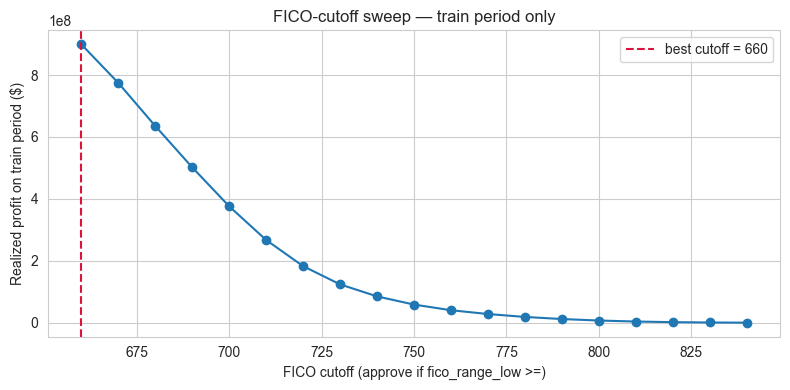

In [15]:
# Plot the FICO sweep on train so we can see the shape
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_results["cutoff"], train_results["train_profit"], marker="o")
ax.axvline(best_cutoff, color="crimson", linestyle="--", label=f"best cutoff = {best_cutoff}")
ax.set_xlabel("FICO cutoff (approve if fico_range_low >=)")
ax.set_ylabel("Realized profit on train period ($)")
ax.set_title("FICO-cutoff sweep — train period only")
ax.legend()
plt.tight_layout()
plt.show()

## Takeaways

- **Default rate trend.** Climbs from ~13% (2009) to ~23% (2016–17), then drops to 16% in 2018 — that 2018 dip is the maturity-censoring signature, not a real improvement. The temporal split is justified.
- **LC's own grading has signal.** Default rate goes from 6% (grade A) to 50% (grade G).
- **Maturity bias confirmed.** Charged-off mean realized profit drops from ≈ -$5,000 in 2010–2013 to **-$14,338 in 2018** — early defaulters dominate the recent vintages because the rest are still in flight.
- **After the maturity filter:** train = 691k matured loans (2007–2015), test = 109k (Jan–Apr 2016, all 36-month). Per-loan baseline profit flips from -$725 to **+$530**.
- **FICO cutoff is degenerate.** Best cutoff on train is the grid floor (660 = LC's policy minimum), so `fico ≥ 660` ≡ approve-all. The model has to win by *jointly* using features, not by raising a single threshold.

The bar for `03_modeling`: beat $530/loan on a 109k-loan test set.